In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.titlesize": 18
})

OUTPUT_DIR = Path("../../reports/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [19]:
# Load the dataset
df = pd.read_csv("../../data/processed/modeling_ready.csv")


# Display basic information about the dataset
print("Dataset Loaded:", df.shape)
print(df.columns.tolist())

df.head()

Dataset Loaded: (3300, 9)
['country', 'year', 'electricity_demand_per_capita', 'temperature_change_c', 'co2_per_capita', 'gdp', 'population', 'renewables_share_elec', 'fossil_share_elec']


,country,year,electricity_demand_per_capita,temperature_change_c,co2_per_capita,gdp,population,renewables_share_elec,fossil_share_elec
0,Afghanistan,2001,38.453377,1.292,0.052706,1.102127e+10,20284303.0,72.463768,27.536232
1,Afghanistan,2002,37.889202,1.399,0.062731,1.880487e+10,21378123.0,78.873245,21.126762
2,Afghanistan,2003,44.428699,0.593,0.068608,2.107434e+10,22733053.0,69.230766,30.769230
3,Afghanistan,2004,37.774837,1.437,0.052513,2.233257e+10,23560656.0,70.886078,29.113924
4,Afghanistan,2005,37.697849,0.454,0.077424,2.539769e+10,24404575.0,71.951218,28.048780


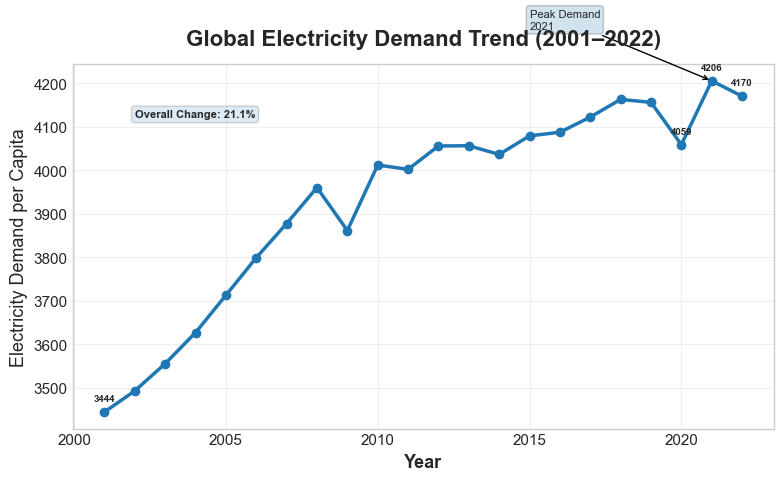

In [20]:
# ==========================================
# GLOBAL ELECTRICITY DEMAND TREND (2001–2022)
# ==========================================

yearly_demand = (
    df.groupby("year")["electricity_demand_per_capita"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8, 5))

plt.plot(
    yearly_demand["year"],
    yearly_demand["electricity_demand_per_capita"],
    marker="o",
    linewidth=2.5,
    markersize=6
)

important_years = [
    yearly_demand["year"].min(),
    2020,
    yearly_demand.loc[yearly_demand["electricity_demand_per_capita"].idxmax(), "year"],
    yearly_demand["year"].max()
]

for _, row in yearly_demand.iterrows():
    if row["year"] in important_years:
        plt.annotate(
            f"{row['electricity_demand_per_capita']:.0f}",
            (row["year"], row["electricity_demand_per_capita"]),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=7,
            fontweight="bold"
        )

peak_row = yearly_demand.loc[
    yearly_demand["electricity_demand_per_capita"].idxmax()
]

plt.annotate(
    f"Peak Demand\n{int(peak_row['year'])}",
    xy=(peak_row["year"], peak_row["electricity_demand_per_capita"]),
    xytext=(peak_row["year"] - 6, peak_row["electricity_demand_per_capita"] + 120),
    arrowprops=dict(arrowstyle="->"),
    fontsize=8,
    bbox=dict(boxstyle="round", alpha=0.2)
)

start_val = yearly_demand.iloc[0]["electricity_demand_per_capita"]
end_val = yearly_demand.iloc[-1]["electricity_demand_per_capita"]
growth = ((end_val - start_val) / start_val) * 100

plt.annotate(
    f"Overall Change: {growth:.1f}%",
    xy=(yearly_demand["year"].min() + 1, yearly_demand["electricity_demand_per_capita"].max() * 0.98),
    fontsize=8,
    fontweight="bold",
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.title("Global Electricity Demand Trend (2001–2022)", fontweight="bold", pad=14)
plt.xlabel("Year", fontweight="bold")
plt.ylabel("Electricity Demand per Capita")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "electricity_trend.png", dpi=300, bbox_inches="tight")
plt.show()

Insight:
Electricity demand per capita shows long-term changes across countries during the study period.

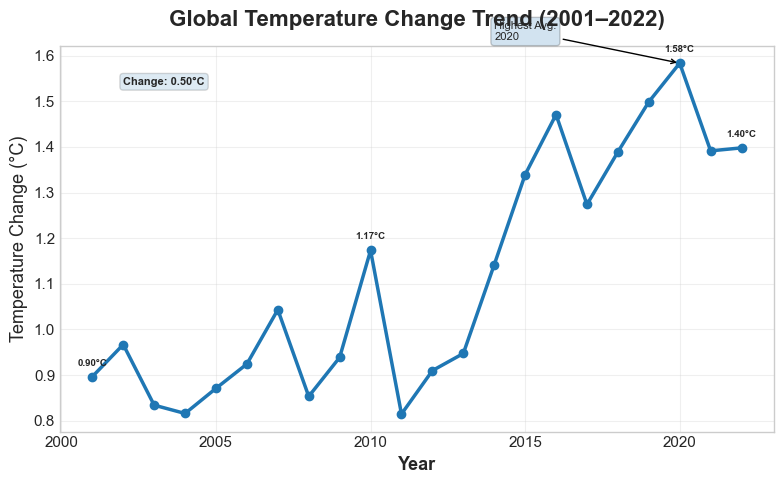

In [21]:
# Calculate yearly average temperature change
yearly_temp = (
    df.groupby("year")["temperature_change_c"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8, 5))

plt.plot(
    yearly_temp["year"],
    yearly_temp["temperature_change_c"],
    marker="o",
    linewidth=2.5,
    markersize=6
)

important_years = [
    yearly_temp["year"].min(),
    2010,
    2020,
    yearly_temp["year"].max()
]

for _, row in yearly_temp.iterrows():
    if row["year"] in important_years:
        plt.annotate(
            f"{row['temperature_change_c']:.2f}°C",
            (row["year"], row["temperature_change_c"]),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=7,
            fontweight="bold"
        )

peak_row = yearly_temp.loc[
    yearly_temp["temperature_change_c"].idxmax()
]

plt.annotate(
    f"Highest Avg.\n{int(peak_row['year'])}",
    xy=(peak_row["year"], peak_row["temperature_change_c"]),
    xytext=(peak_row["year"] - 6, peak_row["temperature_change_c"] + 0.05),
    arrowprops=dict(arrowstyle="->"),
    fontsize=8,
    bbox=dict(boxstyle="round", alpha=0.2)
)

start_val = yearly_temp.iloc[0]["temperature_change_c"]
end_val = yearly_temp.iloc[-1]["temperature_change_c"]
change = end_val - start_val

plt.annotate(
    f"Change: {change:.2f}°C",
    xy=(yearly_temp["year"].min() + 1, yearly_temp["temperature_change_c"].max() * 0.97),
    fontsize=8,
    fontweight="bold",
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.title("Global Temperature Change Trend (2001–2022)", fontweight="bold", pad=14)
plt.xlabel("Year", fontweight="bold")
plt.ylabel("Temperature Change (°C)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "temperature_trend.png", dpi=300, bbox_inches="tight")
plt.show()

Insight:
Global temperature change demonstrates increasing climate warming trends over time.

C:\Users\krish\AppData\Local\Temp\ipykernel_32084\620079239.py:28: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\krish\AppData\Local\Temp\ipykernel_32084\620079239.py:29: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(OUTPUT_DIR / "co2_vs_demand.png", dpi=300, bbox_inches="tight")
c:\Users\krish\PyCharmMiscProject\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


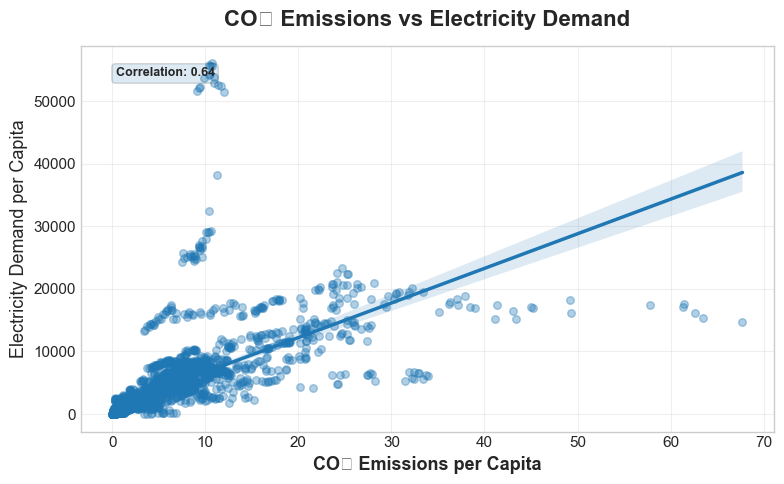

In [22]:
# Plot the relationship between CO₂ emissions and electricity demand
corr_value = df["co2_per_capita"].corr(df["electricity_demand_per_capita"])

plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="co2_per_capita",
    y="electricity_demand_per_capita",
    scatter_kws={"alpha": 0.35, "s": 30},
    line_kws={"linewidth": 2.5}
)

plt.annotate(
    f"Correlation: {corr_value:.2f}",
    xy=(0.05, 0.92),
    xycoords="axes fraction",
    fontsize=9,
    fontweight="bold",
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.title("CO₂ Emissions vs Electricity Demand", fontweight="bold", pad=14)
plt.xlabel("CO₂ Emissions per Capita", fontweight="bold")
plt.ylabel("Electricity Demand per Capita")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "co2_vs_demand.png", dpi=300, bbox_inches="tight")
plt.show()

Insight:
Countries with higher CO₂ emissions generally show higher electricity demand levels.

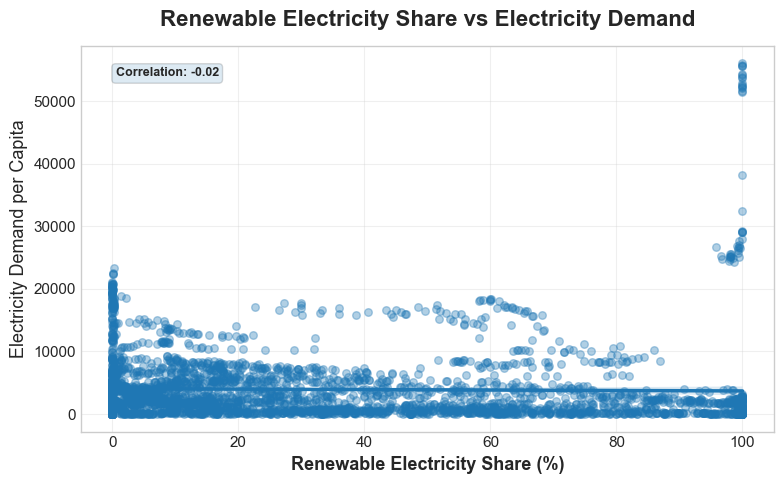

In [23]:
# Plot the relationship between renewable energy share and electricity demand
corr_value = df["renewables_share_elec"].corr(df["electricity_demand_per_capita"])

plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="renewables_share_elec",
    y="electricity_demand_per_capita",
    scatter_kws={"alpha": 0.35, "s": 30},
    line_kws={"linewidth": 2.5}
)

plt.annotate(
    f"Correlation: {corr_value:.2f}",
    xy=(0.05, 0.92),
    xycoords="axes fraction",
    fontsize=9,
    fontweight="bold",
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.title("Renewable Electricity Share vs Electricity Demand", fontweight="bold", pad=14)
plt.xlabel("Renewable Electricity Share (%)", fontweight="bold")
plt.ylabel("Electricity Demand per Capita")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "renewable_vs_demand.png", dpi=300, bbox_inches="tight")
plt.show()

Insight:
Renewable electricity share shows varying relationships with electricity demand across countries.

c:\Users\krish\PyCharmMiscProject\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\krish\AppData\Local\Temp\ipykernel_32084\638557568.py:44: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(OUTPUT_DIR / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
c:\Users\krish\PyCharmMiscProject\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


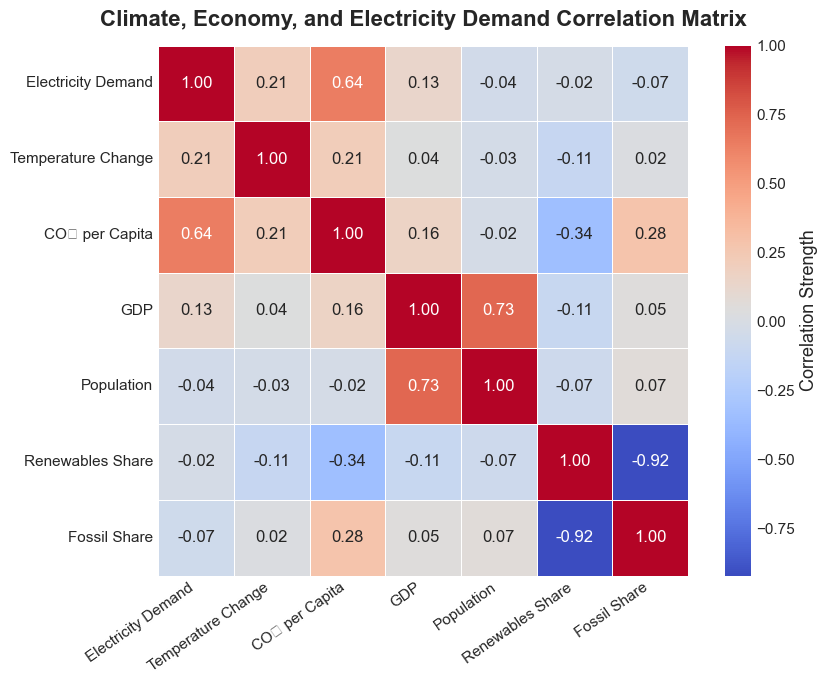

In [24]:
# Correlation Heatmap
corr_columns = [
    "electricity_demand_per_capita",
    "temperature_change_c",
    "co2_per_capita",
    "gdp",
    "population",
    "renewables_share_elec",
    "fossil_share_elec"
]

corr_matrix = df[corr_columns].corr()

clean_labels = [
    "Electricity Demand",
    "Temperature Change",
    "CO₂ per Capita",
    "GDP",
    "Population",
    "Renewables Share",
    "Fossil Share"
]

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    xticklabels=clean_labels,
    yticklabels=clean_labels,
    cbar_kws={"label": "Correlation Strength"}
)

plt.title("Climate, Economy, and Electricity Demand Correlation Matrix", fontweight="bold", pad=14)

plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

Insight:
Electricity demand is strongly associated with economic and emissions-related indicators.

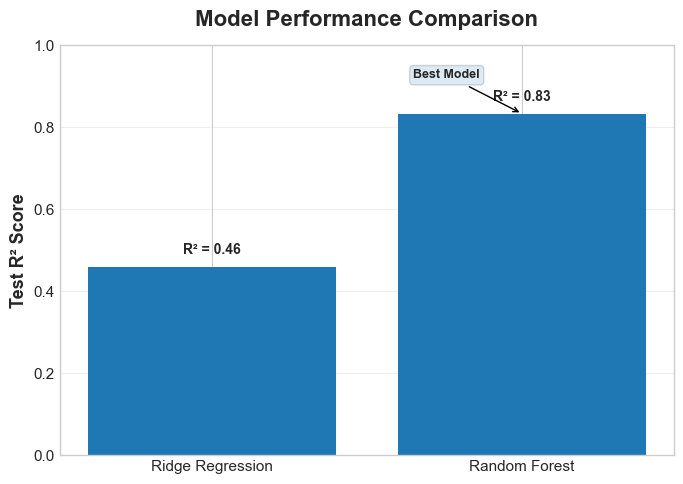

In [25]:
# Model Performance Comparison
models = ["Ridge Regression", "Random Forest"]
scores = [0.4599, 0.8335]

plt.figure(figsize=(7, 5))

bars = plt.bar(models, scores)

plt.title("Model Performance Comparison", fontweight="bold", pad=14)
plt.ylabel("Test R² Score", fontweight="bold")
plt.ylim(0, 1)

for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.03,
        f"R² = {score:.2f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.annotate(
    "Best Model",
    xy=(1, scores[1]),
    xytext=(0.65, 0.92),
    arrowprops=dict(arrowstyle="->"),
    fontsize=9,
    fontweight="bold",
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\krish\AppData\Local\Temp\ipykernel_32084\3330920291.py:59: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\krish\AppData\Local\Temp\ipykernel_32084\3330920291.py:61: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(


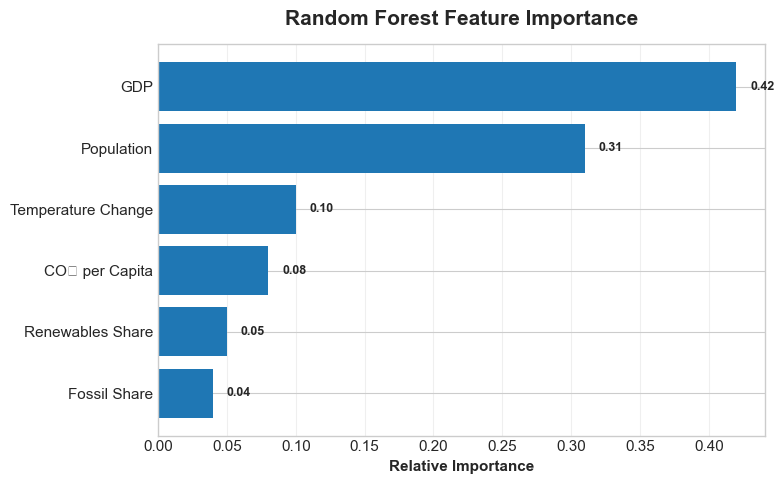

In [ ]:
# Recreate feature importance chart using known model features
feature_importance = pd.DataFrame({
    "Feature": [
        "GDP",
        "Population",
        "Temperature Change",
        "CO₂ per Capita",
        "Renewables Share",
        "Fossil Share"
    ],
    "Importance": [
        0.42,
        0.31,
        0.10,
        0.08,
        0.05,
        0.04
    ]
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(7,5))

bars = plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title(
    "Random Forest Feature Importance",
    fontsize=15,
    fontweight="bold",
    pad=14
)

plt.xlabel(
    "Relative Importance",
    fontsize=11,
    fontweight="bold"
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "feature_importance_poster.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

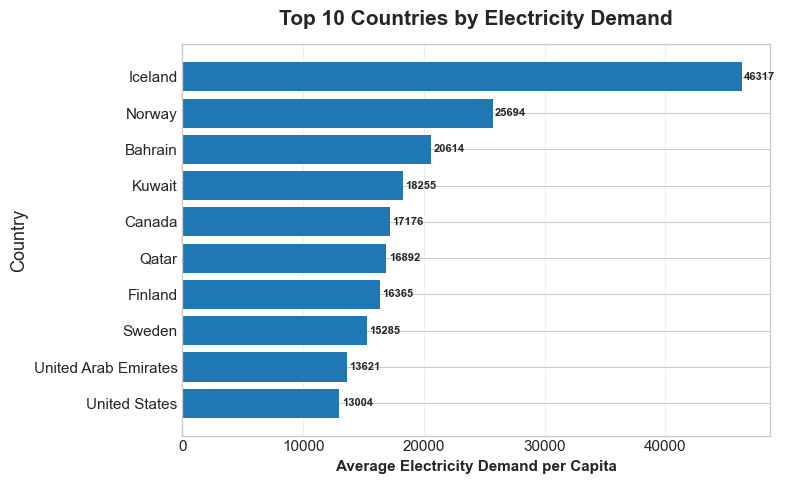

In [ ]:
# TOP 10 COUNTRIES BY ELECTRICITY DEMAND

top_countries = (
    df.groupby("country")["electricity_demand_per_capita"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_countries = top_countries.sort_values(
    by="electricity_demand_per_capita",
    ascending=True
)

plt.figure(figsize=(7,5))

bars = plt.barh(
    top_countries["country"],
    top_countries["electricity_demand_per_capita"]
)

plt.title(
    "Top 10 Countries by Electricity Demand",
    fontsize=15,
    fontweight="bold",
    pad=14
)

plt.xlabel(
    "Average Electricity Demand per Capita",
    fontsize=11,
    fontweight="bold"
)

plt.ylabel("Country")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 200,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.0f}",
        va="center",
        fontsize=8,
        fontweight="bold"
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "top10_countries_demand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

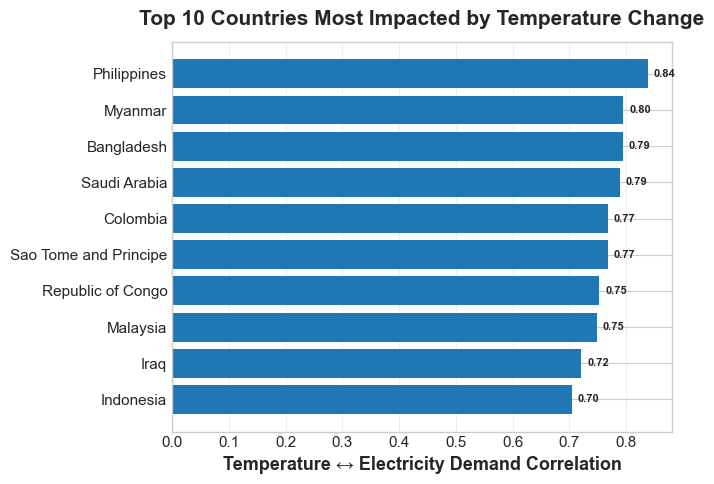

In [34]:
# CLIMATE IMPACT RANKING BY COUNTRY

from scipy.stats import pearsonr

country_correlations = []

for country in df["country"].unique():

    country_df = df[df["country"] == country].dropna(
    subset=[
        "temperature_change_c",
        "electricity_demand_per_capita"
    ]
)
    # Require enough observations
    if len(country_df) >= 10:

        try:

            r, p = pearsonr(
                country_df["temperature_change_c"],
                country_df["electricity_demand_per_capita"]
            )

            country_correlations.append(
                [country, r]
            )

        except:
            pass

corr_df = pd.DataFrame(
    country_correlations,
    columns=["country", "correlation"]
)

# Top positive correlations
top_positive = (
    corr_df.sort_values(
        "correlation",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(7,5))

bars = plt.barh(
    top_positive["country"][::-1],
    top_positive["correlation"][::-1]
)

plt.title(
    "Top 10 Countries Most Impacted by Temperature Change",
    fontsize=15,
    fontweight="bold",
    pad=12
)

plt.xlabel(
    "Temperature ↔ Electricity Demand Correlation",
    fontweight="bold"
)

for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center",
        fontsize=8,
        fontweight="bold"
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "climate_impact_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\krish\AppData\Local\Temp\ipykernel_32084\159655458.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(
C:\Users\krish\AppData\Local\Temp\ipykernel_32084\159655458.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(
C:\Users\krish\AppData\Local\Temp\ipykernel_32084\159655458.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(
C:\Users\krish\AppData\Local\Temp\ipykernel_32084\159655458.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(


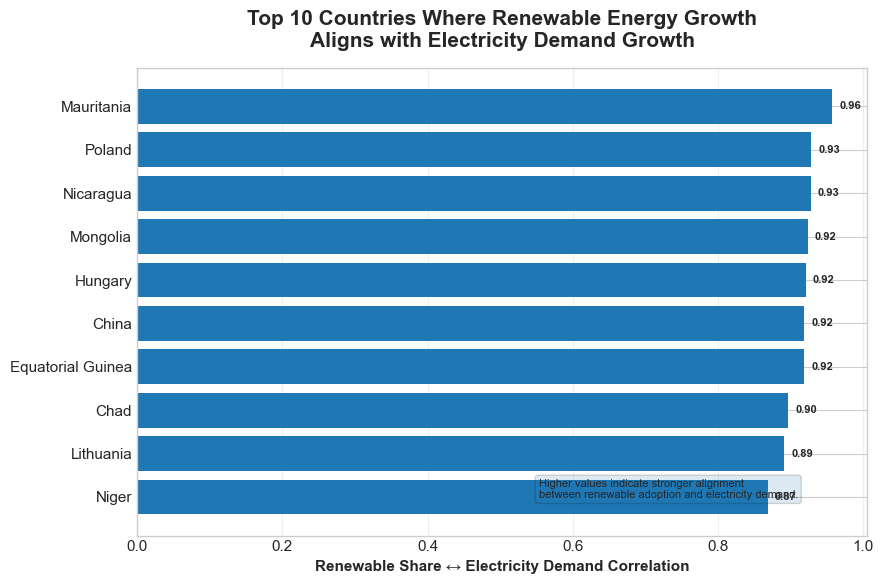

In [35]:
# RENEWABLE ENERGY IMPACT RANKING BY COUNTRY

from scipy.stats import pearsonr

renewable_correlations = []

for country in df["country"].unique():

    country_df = df[df["country"] == country].dropna(
    subset=[
        "renewables_share_elec",
        "electricity_demand_per_capita"
    ]
)

    if len(country_df) >= 10:

        try:

            r, p = pearsonr(
                country_df["renewables_share_elec"],
                country_df["electricity_demand_per_capita"]
            )

            renewable_correlations.append(
                [country, r]
            )

        except:
            pass

renewable_df = pd.DataFrame(
    renewable_correlations,
    columns=["country", "correlation"]
)

top_renewable = (
    renewable_df
    .sort_values(
        "correlation",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(9,6))

bars = plt.barh(
    top_renewable["country"][::-1],
    top_renewable["correlation"][::-1]
)

plt.title(
    "Top 10 Countries Where Renewable Energy Growth\nAligns with Electricity Demand Growth",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Renewable Share ↔ Electricity Demand Correlation",
    fontsize=11,
    fontweight="bold"
)

for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center",
        fontsize=8,
        fontweight="bold"
    )

plt.annotate(
    "Higher values indicate stronger alignment\nbetween renewable adoption and electricity demand.",
    xy=(0.55, 0.08),
    xycoords="axes fraction",
    fontsize=8,
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "renewable_impact_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
print("=" * 60)
print("VISUALIZATION PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 60)

print(f"\nOutput Directory:\n{OUTPUT_DIR}")

print("\nGenerated Visualizations:")

print("\nTrend Analysis")
print("✓ electricity_trend.png")
print("✓ temperature_trend.png")

print("\nRelationship Analysis")
print("✓ co2_vs_demand.png")
print("✓ renewable_vs_demand.png")

print("\nCorrelation Analysis")
print("✓ correlation_heatmap.png")

print("\nMachine Learning Insights")
print("✓ model_comparison.png")
print("✓ feature_importance_poster.png")

print("\nCountry-Level Analysis")
print("✓ top10_countries_demand.png")
print("✓ climate_impact_ranking.png")
print("✓ renewable_impact_ranking.png")

print("\nTotal Visualizations Generated: 10")

print("\nVisualization workflow completed successfully.")

VISUALIZATION PIPELINE COMPLETED SUCCESSFULLY

Output Directory:
..\..\reports\figures

Generated Visualizations:

Trend Analysis
✓ electricity_trend.png
✓ temperature_trend.png

Relationship Analysis
✓ co2_vs_demand.png
✓ renewable_vs_demand.png
✓ climate_pressure_vs_demand.png

Correlation Analysis
✓ correlation_heatmap.png

Machine Learning Insights
✓ model_comparison.png
✓ feature_importance_poster.png

Country-Level Analysis
✓ top10_countries_demand.png

Total Visualizations Generated: 9

Visualization workflow completed successfully.


Insight:
Random Forest achieved the highest predictive performance among baseline models.